# ResNet50 Best Tuned

ResNet50 notebook restored toward the original higher-accuracy setup for side-by-side comparison.

In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import regularizers
import os
import random
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"
print("Using data_dir:", data_dir)


Using data_dir: /mnt/e/DDSM/ROI


In [ ]:

img_size = (224, 224)
batch_size = 8
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# 1) Dataset split: train / val / test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("class_name:", class_names)

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = temp_card // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False, cache_path=None):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    if cache_path:
        ds = ds.cache(cache_path)
    return ds.prefetch(AUTOTUNE)
train_ds_prep = prepare(train_ds, shuffle=True, cache_path="/tmp/train_cache")
val_ds_prep   = prepare(val_ds, cache_path="/tmp/val_cache")
test_ds_prep  = prepare(test_ds, cache_path="/tmp/test_cache")

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val   batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test  batches:", tf.data.experimental.cardinality(test_ds).numpy())



# 2) Model: augmentation + ResNet50 + classification head (with regularization)

data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.10),
        keras.layers.RandomZoom(0.20),
        keras.layers.RandomTranslation(0.05, 0.05),
        keras.layers.RandomContrast(0.20),
    ],
    name="data_augmentation"
)

base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=img_size + (3,)
)

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)  # Active only during training
x = keras.applications.resnet50.preprocess_input(x)

# Keep BN in inference mode during the frozen stage
x = base_model(x, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)

# Use a larger dropout rate: 0.5
x = keras.layers.Dropout(0.5)(x)

# Typical choice: 1e-4
l2 = tf.keras.regularizers.l2(1e-4)
outputs = keras.layers.Dense(
    1, activation="sigmoid",
    kernel_regularizer=l2,  # Apply L2 regularization to Dense weights
    bias_regularizer=None
)(x)

model = keras.Model(inputs, outputs)



# 3) Stage 1: freeze the backbone and train only the head

loss_fn = keras.losses.BinaryCrossentropy(label_smoothing=0.05)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_resnet_stage1.keras"
callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
]

initial_epochs = 8
base_model.trainable = False
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,  # Use label smoothing with factor 0.05
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=initial_epochs,
    callbacks=callbacks_stage1
)

# 4) Stage 2: unfreeze only conv5_* and keep all BN layers frozen for small-batch stability
base_model.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("conv5_"):
        layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base_model layers:", len(base_model.layers))
print("Trainable layers:", sum(int(l.trainable) for l in base_model.layers))

best_path = "/mnt/e/SW_training_outputs/checkpoints/best_by_val_auc.keras"

# Reduce the learning rate automatically when val_auc stops improving
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,     # learning rate * 0.5
        patience=2,     # reduce after 2 epochs without improvement
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,     # slightly relaxed patience to work with LR scheduling
        restore_best_weights=False,  # rely on the checkpoint file instead
        verbose=1
    ),
]

# Use AdamW for decoupled weight decay
try:
    opt2 = keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5)
except Exception:
    opt2 = keras.optimizers.Adam(learning_rate=1e-5)

fine_tune_epochs = 50
total_epochs = initial_epochs + fine_tune_epochs

model.compile(
    optimizer=opt2,  # Prefer AdamW
    loss=loss_fn,   # Includes label smoothing
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    callbacks=callbacks_stage2
)

print("Training complete. Best checkpoint saved to:", best_path)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.


I0000 00:00:1773178619.845335    1482 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2830 files belonging to 2 classes.
Using 566 files for validation.
class_name: ['ROI_Benign', 'ROI_Cancer']
train batches: 283
val   batches: 35
test  batches: 36
Epoch 1/8


2026-03-11 05:37:15.950444: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


142/283 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.4824 - auc: 0.4826 - loss: 0.9423

...

2026-03-11 05:39:06.560829: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-03-11 05:39:06.560869: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13640531378903278020
2026-03-11 05:39:06.560875: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12002815231385983232
2026-03-11 05:39:06.560878: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17562850973107729638



Epoch 8: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_resnet_stage1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5786 - auc: 0.6198 - loss: 0.7098 - val_accuracy: 0.6146 - val_auc: 0.7042 - val_loss: 0.6304
Total base_model layers: 175
Trainable layers: 22
Epoch 9/58
142/283 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.5965 - auc: 0.6356 - loss: 0.6827
Epoch 9: val_auc improved from None to 0.72280, saving model to /mnt/e/SW_training_outputs/checkpoints/best_by_val_auc.keras

Epoch 9: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_by_val_auc.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.6122 - auc: 0.6582 - loss: 0.6633 - val_accuracy: 0.6736 - val_auc: 0.7228 - val_loss: 0.6114 - learning_rate: 1.0000e-05
Epoch 10/58
142/283 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.6333 - auc: 0.6850 - loss: 0.6431
Epoch 10: val_auc improved from 0.72280 to 0.73567, saving model to /mnt/e/SW_training_outputs/

2026-03-11 05:41:28.339479: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


142/283 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.6988 - auc: 0.7700 - loss: 0.5772
Epoch 17: val_auc did not improve from 0.74050
283/283 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7155 - auc: 0.7911 - loss: 0.5601 - val_accuracy: 0.6285 - val_auc: 0.7264 - val_loss: 0.6383 - learning_rate: 2.5000e-06
Epoch 18/58
142/283 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.6842 - auc: 0.7719 - loss: 0.5750
Epoch 18: val_auc did not improve from 0.74050

Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
283/283 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.7138 - auc: 0.7967 - loss: 0.5578 - val_accuracy: 0.6597 - val_auc: 0.7310 - val_loss: 0.6241 - learning_rate: 2.5000e-06
Epoch 19/58
142/283 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.7122 - auc: 0.7838 - loss: 0.5605
Epoch 19: val_auc did not improve from 0.74050
283/283 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.7301 - auc: 0.7998 - loss: 0.5498 - val_accuracy: 0.6632 - val_auc: 

2026-03-11 05:42:28.461055: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13640531378903278020
2026-03-11 05:42:28.461110: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12002815231385983232


Loaded best model from: /mnt/e/SW_training_outputs/checkpoints/best_by_val_auc.keras
Best model output shape: (None, 1)
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - acc: 0.7122 - auc: 0.7730 - loss: 0.5657 - precision: 0.7073 - recall: 0.6641 
Evaluation metrics: {'acc': 0.7122302055358887, 'auc': 0.7730436325073242, 'loss': 0.5657277703285217, 'precision': 0.707317054271698, 'recall': 0.6641221642494202}


2026-03-11 05:42:37.879200: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Positive class for ROC/AUC: ROI_Cancer
First 20 y_true: [0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0]
First 20 y_prob: [0.4413 0.1495 0.9884 0.4471 0.6798 0.5705 0.4466 0.2666 0.2173 0.1948
 0.5538 0.6385 0.4253 0.5942 0.1281 0.66   0.2104 0.3285 0.575  0.7776]
Probability range: 0.04100247845053673 0.9986226558685303
Probability mean/std: 0.5130132436752319 0.25548484921455383
Test AUC: 0.7728
Test Accuracy: 0.7122
Confusion Matrix:
 [[111  36]
 [ 44  87]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.72      0.76      0.74       147
  ROI_Cancer       0.71      0.66      0.69       131

    accuracy                           0.71       278
   macro avg       0.71      0.71      0.71       278
weighted avg       0.71      0.71      0.71       278



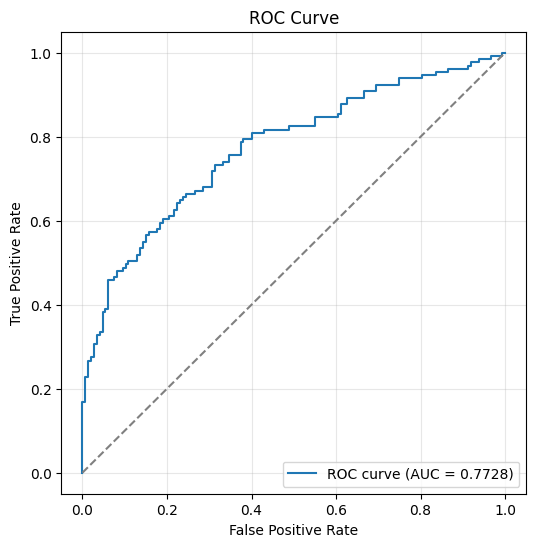

In [5]:
best_model = keras.models.load_model(best_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best model from:", best_path)
print("Best model output shape:", best_model.output_shape)

test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
if not isinstance(test_metrics, dict):
    raise TypeError(
        f"Expected evaluate(..., return_dict=True) to return dict, got {type(test_metrics).__name__}. "
        "Restart the kernel and rerun the notebook from the import cells."
    )
print("Evaluation metrics:", test_metrics)

y_true = []
y_prob = []
for xb, yb in test_ds_prep:
    pb = best_model.predict(xb, verbose=0).reshape(-1)
    y_true.append(yb.numpy().reshape(-1))
    y_prob.append(pb)

y_true = np.concatenate(y_true).astype("int32")
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 y_true:", y_true[:20])
print("First 20 y_prob:", np.round(y_prob[:20], 4))
print("Probability range:", float(y_prob.min()), float(y_prob.max()))
print("Probability mean/std:", float(y_prob.mean()), float(y_prob.std()))

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Test AUC: {auc:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


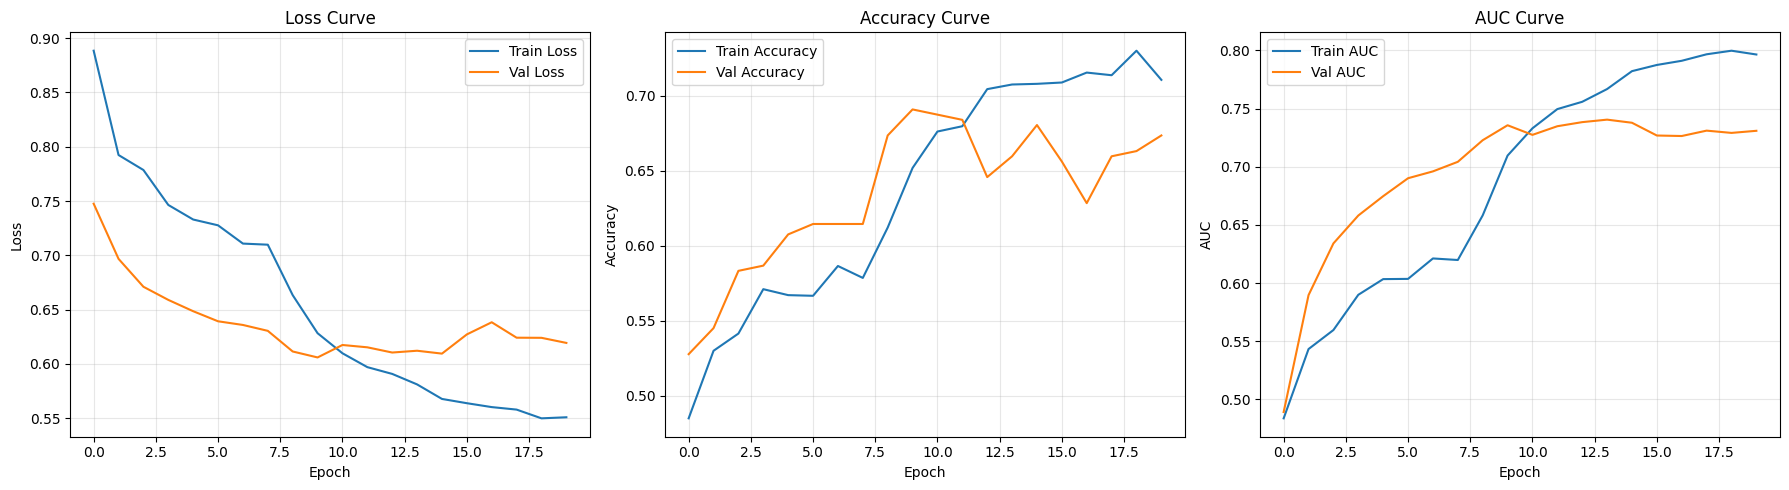

In [6]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

all_history = merge_history(history1, history2)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(all_history["loss"], label="Train Loss")
plt.plot(all_history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
train_acc_key = "acc" if "acc" in all_history else "accuracy"
val_acc_key = "val_acc" if "val_acc" in all_history else "val_accuracy"
plt.plot(all_history[train_acc_key], label="Train Accuracy")
plt.plot(all_history[val_acc_key], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(all_history["auc"], label="Train AUC")
plt.plot(all_history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## End Of Experiment

The cells above train the fair-comparison ResNet50 model, evaluate the saved checkpoint on the test split, and plot the unified learning curves.